In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving demand_forecasting_data.csv to demand_forecasting_data.csv


In [ ]:
import pandas as pd
df = pd.read_csv("demand_forecasting_data.csv")

In [ ]:
df.head()

,Date,Product_ID,Base_Sales,Marketing_Campaign,Marketing_Effect,Seasonal_Trend,Seasonal_Effect,Price,Discount,Competitor_Price,Stock_Availability,Public_Holiday,Demand
0,2019-01-01,P002,65,Social Media,1.634270,Spring,1.0,73.496059,0.078198,64.173418,491,False,60570
1,2019-01-01,P004,94,Social Media,1.240566,Summer,1.2,74.271862,0.182151,69.571391,135,True,18143
2,2019-01-01,P003,125,Radio,1.087600,Summer,1.2,35.274616,0.102592,27.331268,180,False,37412
3,2019-01-01,P004,128,TV,1.831657,Winter,0.8,79.524248,0.196125,73.429502,227,False,40773
4,2019-01-01,P001,51,Radio,1.285161,Fall,1.1,96.237402,0.079253,88.243871,338,False,26917


In [ ]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (35000, 13)

Columns:
['Date', 'Product_ID', 'Base_Sales', 'Marketing_Campaign', 'Marketing_Effect', 'Seasonal_Trend', 'Seasonal_Effect', 'Price', 'Discount', 'Competitor_Price', 'Stock_Availability', 'Public_Holiday', 'Demand']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                35000 non-null  object 
 1   Product_ID          35000 non-null  object 
 2   Base_Sales          35000 non-null  int64  
 3   Marketing_Campaign  27933 non-null  object 
 4   Marketing_Effect    35000 non-null  float64
 5   Seasonal_Trend      35000 non-null  object 
 6   Seasonal_Effect     35000 non-null  float64
 7   Price               35000 non-null  float64
 8   Discount            35000 non-null  float64
 9   Competitor_Price    35000 non-null  float64
 10  Stock_Availability  35000 non-null  int64  
 11  Public_Holiday      35000 non-null  bool   
 12  Demand              35000 non-null  int64  
dtypes: bool(1), float64(5), int64(3), object(4)
memory usage: 3.2+ MB


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date                     0
Product_ID               0
Base_Sales               0
Marketing_Campaign    7067
Marketing_Effect         0
Seasonal_Trend           0
Seasonal_Effect          0
Price                    0
Discount                 0
Competitor_Price         0
Stock_Availability       0
Public_Holiday           0
Demand                   0
dtype: int64


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
print(df.dtypes)

Date                   object
Product_ID             object
Base_Sales              int64
Marketing_Campaign     object
Marketing_Effect      float64
Seasonal_Trend         object
Seasonal_Effect       float64
Price                 float64
Discount              float64
Competitor_Price      float64
Stock_Availability      int64
Public_Holiday           bool
Demand                  int64
dtype: object


In [ ]:
df.describe()

,Base_Sales,Marketing_Effect,Seasonal_Effect,Price,Discount,Competitor_Price,Stock_Availability,Demand
count,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000
mean,124.310857,1.399607,1.023937,64.978204,0.124819,59.474173,254.027686,48237.904000
std,43.370933,0.377013,0.148251,20.129806,0.043347,20.322941,141.721795,37809.256224
min,50.000000,0.960101,0.800000,30.002821,0.050000,20.018921,10.000000,505.000000
25%,87.000000,1.057890,0.800000,47.591650,0.087568,42.157852,131.000000,19637.500000
50%,124.000000,1.320028,1.000000,65.083525,0.124566,59.569889,254.000000,39112.500000
75%,162.000000,1.628659,1.100000,82.392712,0.162095,76.859092,377.000000,67367.000000
max,199.000000,2.399656,1.200000,99.997372,0.199998,98.902377,499.000000,285337.000000


In [ ]:
# Fill missing marketing campaign values
df["Marketing_Campaign"] = df["Marketing_Campaign"].fillna("No Campaign")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

print("Data cleaning completed.")

Data cleaning completed.


In [ ]:
print(df.isnull().sum())

Date                  0
Product_ID            0
Base_Sales            0
Marketing_Campaign    0
Marketing_Effect      0
Seasonal_Trend        0
Seasonal_Effect       0
Price                 0
Discount              0
Competitor_Price      0
Stock_Availability    0
Public_Holiday        0
Demand                0
dtype: int64


In [ ]:
print(df.dtypes)

Date                  datetime64[ns]
Product_ID                    object
Base_Sales                     int64
Marketing_Campaign            object
Marketing_Effect             float64
Seasonal_Trend                object
Seasonal_Effect              float64
Price                        float64
Discount                     float64
Competitor_Price             float64
Stock_Availability             int64
Public_Holiday                  bool
Demand                         int64
dtype: object


In [ ]:
print("Number of unique products:", df["Product_ID"].nunique())

print("\nProduct examples:")
print(df["Product_ID"].unique()[:10])

print("\nMarketing campaigns:")
print(df["Marketing_Campaign"].unique())

print("\nSeasonal trends:")
print(df["Seasonal_Trend"].unique())

Number of unique products: 5

Product examples:
['P002' 'P004' 'P003' 'P001' 'P005']

Marketing campaigns:
['Social Media' 'Radio' 'TV' 'No Campaign' 'Email']

Seasonal trends:
['Spring' 'Summer' 'Winter' 'Fall']


In [ ]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

In [ ]:
features = [
    "Product_ID",
    "Base_Sales",
    "Marketing_Campaign",
    "Marketing_Effect",
    "Seasonal_Trend",
    "Seasonal_Effect",
    "Price",
    "Discount",
    "Competitor_Price",
    "Stock_Availability",
    "Public_Holiday",
    "Year",
    "Month",
    "Day",
    "DayOfWeek"
]

X = df[features]
y = df["Demand"]

print("Input features:", X.shape)
print("Target:", y.shape)

Input features: (35000, 15)
Target: (35000,)


In [ ]:
X = pd.get_dummies(
    X,
    columns=["Product_ID", "Marketing_Campaign", "Seasonal_Trend"],
    drop_first=True
)

print("Features after encoding:", X.shape)
print(X.head())

Features after encoding: (35000, 23)
   Base_Sales  Marketing_Effect  Seasonal_Effect      Price  Discount  \
0          65          1.634270              1.0  73.496059  0.078198   
1          94          1.240566              1.2  74.271862  0.182151   
2         125          1.087600              1.2  35.274616  0.102592   
3         128          1.831657              0.8  79.524248  0.196125   
4          51          1.285161              1.1  96.237402  0.079253   

   Competitor_Price  Stock_Availability  Public_Holiday  Year  Month  ...  \
0         64.173418                 491           False  2019      1  ...   
1         69.571391                 135            True  2019      1  ...   
2         27.331268                 180           False  2019      1  ...   
3         73.429502                 227           False  2019      1  ...   
4         88.243871                 338           False  2019      1  ...   

   Product_ID_P003  Product_ID_P004  Product_ID_P005  \
0    

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (28000, 23)
Testing features: (7000, 23)
Training target: (28000,)
Testing target: (7000,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

print("Models imported successfully")

Models imported successfully


In [ ]:
linear_model = LinearRegression()

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Models created successfully")

Models created successfully


In [ ]:
print("Training Linear Regression...")
linear_model.fit(X_train, y_train)
print("Linear Regression completed.")

print("Training Random Forest...")
random_forest_model.fit(X_train, y_train)
print("Random Forest completed.")

print("Training Gradient Boosting...")
gradient_boosting_model.fit(X_train, y_train)
print("Gradient Boosting completed.")

print("Training XGBoost...")
xgb_model.fit(X_train, y_train)
print("XGBoost completed.")

print("All models trained successfully!")

Training Linear Regression...
Linear Regression completed.
Training Random Forest...
Random Forest completed.
Training Gradient Boosting...
Gradient Boosting completed.
Training XGBoost...
XGBoost completed.
All models trained successfully!


In [ ]:
# Make predictions using all trained models

linear_pred = linear_model.predict(X_test)

random_forest_pred = random_forest_model.predict(X_test)

gradient_boosting_pred = gradient_boosting_model.predict(X_test)

xgb_pred = xgb_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(actual, predicted)

    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

results = []

results.append(
    evaluate_model("Linear Regression", y_test, linear_pred)
)

results.append(
    evaluate_model("Random Forest", y_test, random_forest_pred)
)

results.append(
    evaluate_model("Gradient Boosting", y_test, gradient_boosting_pred)
)

results.append(
    evaluate_model("XGBoost", y_test, xgb_pred)
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,9925.438928,1.919323e+08,13853.963620,0.861458
1,Random Forest,3012.044327,2.323771e+07,4820.550737,0.983226
2,Gradient Boosting,3361.322917,2.513454e+07,5013.436195,0.981857
3,XGBoost,2073.068848,9.262244e+06,3043.393501,0.993314


In [ ]:
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully")

GridSearchCV imported successfully


In [ ]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

print("Parameter grid created")

Parameter grid created


In [ ]:
grid_search = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV model created")

GridSearchCV model created


In [ ]:
grid_search.fit(X_train, y_train)

print("GridSearchCV completed!")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
GridSearchCV completed!


In [ ]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV score:")
print(grid_search.best_score_)

Best parameters:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

Best CV score:
-7415716.166666667


In [ ]:
# Get the best XGBoost model
best_xgb_model = grid_search.best_estimator_

# Make predictions on test data
tuned_xgb_pred = best_xgb_model.predict(X_test)

# Calculate evaluation metrics
tuned_mae = mean_absolute_error(y_test, tuned_xgb_pred)
tuned_mse = mean_squared_error(y_test, tuned_xgb_pred)
tuned_rmse = np.sqrt(tuned_mse)
tuned_r2 = r2_score(y_test, tuned_xgb_pred)

print("Tuned XGBoost Results")
print("---------------------")
print("MAE :", tuned_mae)
print("MSE :", tuned_mse)
print("RMSE:", tuned_rmse)
print("R2  :", tuned_r2)

Tuned XGBoost Results
---------------------
MAE : 1469.8050537109375
MSE : 5396814.0
RMSE: 2323.104388528419
R2  : 0.9961044192314148


In [ ]:
print("Original XGBoost")
print("----------------")
print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("MSE :", mean_squared_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2  :", r2_score(y_test, xgb_pred))

print("\nTuned XGBoost")
print("-------------")
print("MAE :", tuned_mae)
print("MSE :", tuned_mse)
print("RMSE:", tuned_rmse)
print("R2  :", tuned_r2)

Original XGBoost
----------------
MAE : 2073.06884765625
MSE : 9262244.0
RMSE: 3043.393500683078
R2  : 0.993314266204834

Tuned XGBoost
-------------
MAE : 1469.8050537109375
MSE : 5396814.0
RMSE: 2323.104388528419
R2  : 0.9961044192314148


In [ ]:
import joblib

In [ ]:
joblib.dump(best_xgb_model, "demand_prediction_model.pkl")

print("Demand prediction model saved successfully!")

Demand prediction model saved successfully!


In [ ]:
joblib.dump(X.columns.tolist(), "demand_model_features.pkl")

print("Feature list saved successfully!")

Feature list saved successfully!


In [ ]:
# Get feature importance from the trained XGBoost model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.to_string(index=False))

                        Feature  Importance
             Stock_Availability    0.435166
                     Base_Sales    0.222290
               Marketing_Effect    0.182504
                Seasonal_Effect    0.109320
          Marketing_Campaign_TV    0.018668
                       Discount    0.010996
               Competitor_Price    0.010673
                          Price    0.002384
 Marketing_Campaign_No Campaign    0.002133
                Product_ID_P004    0.000773
                 Public_Holiday    0.000656
                          Month    0.000592
                      DayOfWeek    0.000568
                           Year    0.000537
                            Day    0.000471
       Marketing_Campaign_Radio    0.000444
                Product_ID_P005    0.000442
                Product_ID_P002    0.000441
          Seasonal_Trend_Spring    0.000347
                Product_ID_P003    0.000334
Marketing_Campaign_Social Media    0.000262
          Seasonal_Trend_Summer 

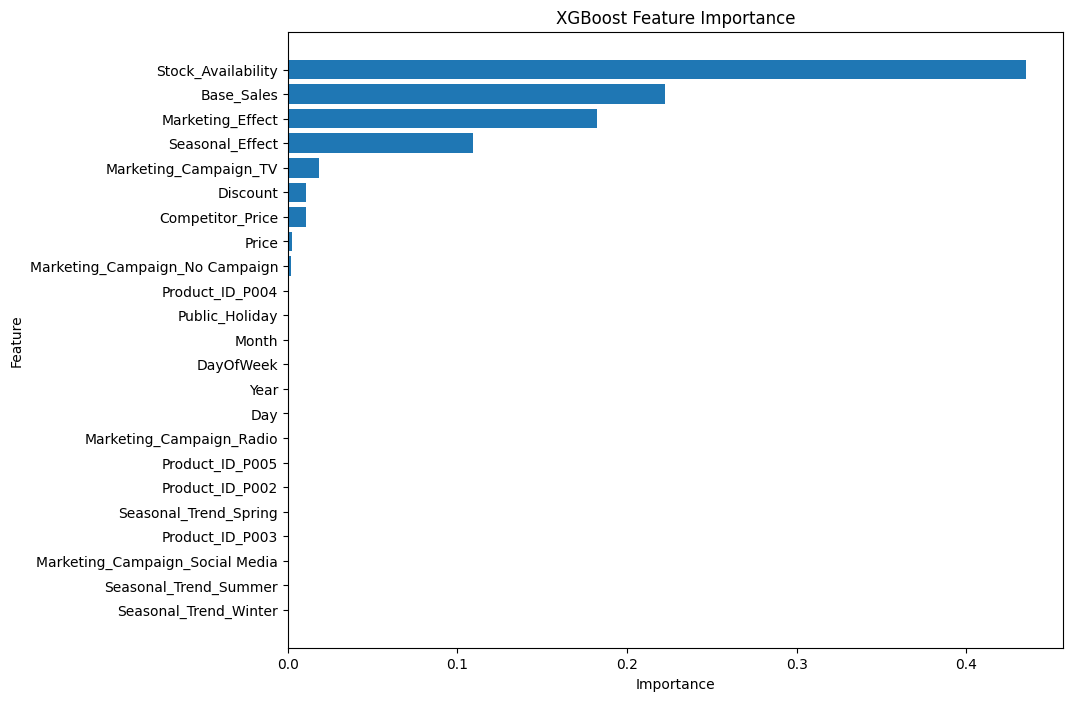

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [ ]:
pricing_columns = [
    "Price",
    "Discount",
    "Competitor_Price",
    "Demand",
    "Base_Sales",
    "Stock_Availability"
]

df[pricing_columns].describe()

,Price,Discount,Competitor_Price,Demand,Base_Sales,Stock_Availability
count,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000,35000.000000
mean,64.978204,0.124819,59.474173,48237.904000,124.310857,254.027686
std,20.129806,0.043347,20.322941,37809.256224,43.370933,141.721795
min,30.002821,0.050000,20.018921,505.000000,50.000000,10.000000
25%,47.591650,0.087568,42.157852,19637.500000,87.000000,131.000000
50%,65.083525,0.124566,59.569889,39112.500000,124.000000,254.000000
75%,82.392712,0.162095,76.859092,67367.000000,162.000000,377.000000
max,99.997372,0.199998,98.902377,285337.000000,199.000000,499.000000


In [ ]:
df[pricing_columns].corr(numeric_only=True)

,Price,Discount,Competitor_Price,Demand,Base_Sales,Stock_Availability
Price,1.000000,0.002816,0.991748,-0.044081,0.005093,0.001793
Discount,0.002816,1.000000,0.003556,-0.056421,0.004702,0.011310
Competitor_Price,0.991748,0.003556,1.000000,-0.052435,0.005282,0.001792
Demand,-0.044081,-0.056421,-0.052435,1.000000,0.440652,0.709420
Base_Sales,0.005093,0.004702,0.005282,0.440652,1.000000,0.000243
Stock_Availability,0.001793,0.011310,0.001792,0.709420,0.000243,1.000000


In [ ]:
print("Minimum Price:", df["Price"].min())
print("Maximum Price:", df["Price"].max())
print("Average Price:", df["Price"].mean())

Minimum Price: 30.002821337606207
Maximum Price: 99.9973724803626
Average Price: 64.97820393400261


In [ ]:
candidate_prices = np.linspace(
    df["Price"].min(),
    df["Price"].max(),
    15
)

print(candidate_prices)

[30.00282134 35.00243213 40.00204293 45.00165373 50.00126452 55.00087532
 60.00048611 65.00009691 69.9997077  74.9993185  79.9989293  84.99854009
 89.99815089 94.99776168 99.99737248]


In [ ]:
sample = df.iloc[0].copy()

print(sample)

Date                  2019-01-01 00:00:00
Product_ID                           P002
Base_Sales                             65
Marketing_Campaign           Social Media
Marketing_Effect                  1.63427
Seasonal_Trend                     Spring
Seasonal_Effect                       1.0
Price                           73.496059
Discount                         0.078198
Competitor_Price                64.173418
Stock_Availability                    491
Public_Holiday                      False
Demand                              60570
Year                                 2019
Month                                   1
Day                                     1
DayOfWeek                               1
Name: 0, dtype: object


In [ ]:
# Create a copy of the sample
sample_data = sample.copy()

results = []

for price in candidate_prices:

    # Change only the price
    sample_data["Price"] = price

    # Convert sample into DataFrame
    temp = pd.DataFrame([sample_data])

    # Remove Demand because it is the target
    temp = temp.drop(columns=["Demand"])

    # Convert categorical columns into numerical columns
    temp = pd.get_dummies(
        temp,
        columns=["Product_ID", "Marketing_Campaign", "Seasonal_Trend"],
        drop_first=True
    )

    # Make sure the columns are exactly the same as the training data
    temp = temp.reindex(columns=X.columns, fill_value=0)

    # Predict demand
    predicted_demand = best_xgb_model.predict(temp)[0]

    # Calculate expected revenue
    expected_revenue = price * predicted_demand

    results.append([
        price,
        predicted_demand,
        expected_revenue
    ])

# Convert results into a DataFrame
pricing_results = pd.DataFrame(
    results,
    columns=["Candidate_Price", "Predicted_Demand", "Expected_Revenue"]
)

pricing_results

,Candidate_Price,Predicted_Demand,Expected_Revenue
0,30.002821,50441.703125,1.513393e+06
1,35.002432,48934.421875,1.712824e+06
2,40.002043,49961.480469,1.998561e+06
3,45.001654,52062.144531,2.342883e+06
4,50.001265,53247.281250,2.662431e+06
5,55.000875,54767.964844,3.012286e+06
6,60.000486,56038.109375,3.362314e+06
7,65.000097,56747.222656,3.688575e+06
8,69.999708,59301.355469,4.151078e+06
9,74.999319,61751.593750,4.631327e+06


In [ ]:
# Find the price with the highest expected revenue
best_price_row = pricing_results.loc[
    pricing_results["Expected_Revenue"].idxmax()
]

print("Recommended Price:", best_price_row["Candidate_Price"])
print("Predicted Demand:", best_price_row["Predicted_Demand"])
print("Expected Revenue:", best_price_row["Expected_Revenue"])

Recommended Price: 99.9973724803626
Predicted Demand: 63428.22265625
Expected Revenue: 6342655.606724406
